In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

df = pd.read_csv("diabetes.csv")

print("Dimensión:", df.shape)
print(df.head())
print("Valores faltantes por columna:")
print(df.isna().sum())
print("Distribución de Outcome:")
print(df["Outcome"].value_counts().sort_index())


Dimensión: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
Valores faltantes por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome     

In [5]:
# Eventos expresados como variables booleanas
D = df["Outcome"].eq(1)
G = df["Glucose"].ge(140)
M = df["BMI"].ge(30)
A = df["Age"].ge(40)

def prob(evento):
    return evento.mean()

def prob_condicional(A_evento, B_evento):
    # Calcula P(A | B)
    if B_evento.sum() == 0:
        return np.nan
    return (A_evento & B_evento).sum() / B_evento.sum()

print("P(D)       =", round(prob(D), 4))
print("P(G)       =", round(prob(G), 4))
print("P(D ∩ G)   =", round(prob(D & G), 4))
print("P(D | G)   =", round(prob_condicional(D, G), 4))
print("P(G | D)   =", round(prob_condicional(G, D), 4))
print("P(D | Gᶜ)  =", round(prob_condicional(D, ~G), 4))

tabla_D_G = pd.crosstab(
    df["Outcome"], G,
    rownames=["Outcome"], colnames=["Glucose >= 140"],
    margins=True)
print(tabla_D_G)

P(D)       = 0.349
P(G)       = 0.2591
P(D ∩ G)   = 0.1784
P(D | G)   = 0.6884
P(G | D)   = 0.5112
P(D | Gᶜ)  = 0.2302
Glucose >= 140  False  True  All
Outcome                         
0                 438    62  500
1                 131   137  268
All               569   199  768


In [6]:
p_G = prob(G)
p_noG = 1 - p_G
p_D_dado_G = prob_condicional(D, G)
p_D_dado_noG = prob_condicional(D, ~G)

p_D_total = p_D_dado_G * p_G + p_D_dado_noG * p_noG

print("P(D) directa       =", round(prob(D), 6))
print("P(D) por total     =", round(p_D_total, 6))
print("¿Coinciden?        =", np.isclose(prob(D), p_D_total))


P(D) directa       = 0.348958
P(D) por total     = 0.348958
¿Coinciden?        = True


In [7]:
X = df.drop(columns="Outcome")
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

modelo = Pipeline(steps=[
    ("escala", StandardScaler()),
    ("logistica", LogisticRegression(max_iter=2000, random_state=42))
])

modelo.fit(X_train, y_train)

# Probabilidad estimada de Outcome = 1 para cada observación de prueba
y_prob = modelo.predict_proba(X_test)[:, 1]

# Clasificación con umbral 0.50
umbral = 0.50
y_pred = (y_prob >= umbral).astype(int)

print("Tamaño de entrenamiento:", len(y_train))
print("Tamaño de prueba:", len(y_test))
print("Primeras probabilidades:", np.round(y_prob[:10], 3))


Tamaño de entrenamiento: 614
Tamaño de prueba: 154
Primeras probabilidades: [0.477 0.074 0.37  0.338 0.032 0.103 0.56  0.902 0.067 0.904]


Matriz de confusión:
[[79 21]
 [24 30]]
TN=79, FP=21, FN=24, TP=30
Sensibilidad: 0.5556
Especificidad: 0.7900
VPP:           0.5882
Exactitud:     0.7078


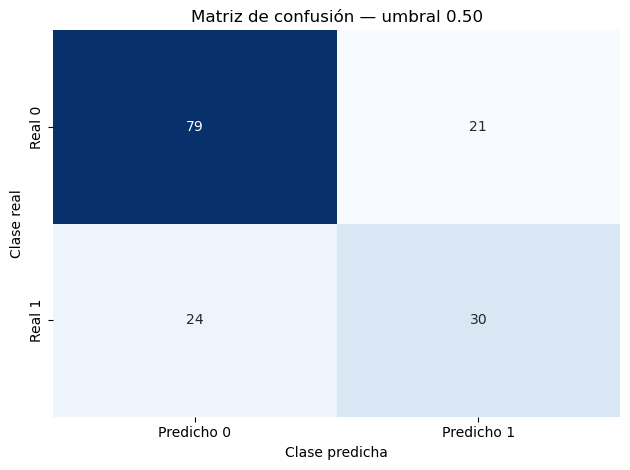

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
TN, FP, FN, TP = cm.ravel()

sensibilidad = TP / (TP + FN)
especificidad = TN / (TN + FP)
vpp_directo = TP / (TP + FP)
exactitud_directa = (TP + TN) / cm.sum()

print("Matriz de confusión:")
print(cm)
print(f"TN={TN}, FP={FP}, FN={FN}, TP={TP}")
print(f"Sensibilidad: {sensibilidad:.4f}")
print(f"Especificidad: {especificidad:.4f}")
print(f"VPP:           {vpp_directo:.4f}")
print(f"Exactitud:     {exactitud_directa:.4f}")

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", cbar=False,
    xticklabels=["Predicho 0", "Predicho 1"],
    yticklabels=["Real 0", "Real 1"]
)
plt.title("Matriz de confusión — umbral 0.50")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()



In [10]:
prevalencia_test = y_test.mean()              # P(D)
p_noD_test = 1 - prevalencia_test              # P(Dᶜ)
tasa_falsos_positivos = 1 - especificidad       # P(+ | Dᶜ)

numerador = sensibilidad * prevalencia_test
p_pred_positivo = (
    sensibilidad * prevalencia_test
    + tasa_falsos_positivos * p_noD_test
)
vpp_bayes = numerador / p_pred_positivo

print(f"VPP directo: {vpp_directo:.6f}")
print(f"VPP por Bayes: {vpp_bayes:.6f}")
print("¿Coinciden?", np.isclose(vpp_directo, vpp_bayes))



VPP directo: 0.588235
VPP por Bayes: 0.588235
¿Coinciden? True


In [11]:
exactitud_total = (
    sensibilidad * prevalencia_test
    + especificidad * p_noD_test
)

print(f"Exactitud directa:   {exactitud_directa:.6f}")
print(f"Exactitud por total: {exactitud_total:.6f}")
print("¿Coinciden?", np.isclose(exactitud_directa, exactitud_total))


Exactitud directa:   0.707792
Exactitud por total: 0.707792
¿Coinciden? True


In [12]:
resultados = []

for u in [0.30, 0.50, 0.70]:
    pred_u = (y_prob >= u).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_test, pred_u, labels=[0, 1]
    ).ravel()

    resultados.append({
        "umbral": u,
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "sensibilidad": tp / (tp + fn),
        "especificidad": tn / (tn + fp),
        "VPP": tp / (tp + fp) if (tp + fp) > 0 else np.nan,
        "exactitud": (tp + tn) / (tp + fp + fn + tn)
    })

tabla_umbrales = pd.DataFrame(resultados)
print(tabla_umbrales.round(3))


   umbral  TP  FP  FN  TN  sensibilidad  especificidad    VPP  exactitud
0     0.3  48  29   6  71         0.889           0.71  0.623      0.773
1     0.5  30  21  24  79         0.556           0.79  0.588      0.708
2     0.7  23   9  31  91         0.426           0.91  0.719      0.740


   prevalencia  VPP_estimado
0         0.50        0.7257
1         0.35        0.5875
2         0.10        0.2272
3         0.01        0.0260


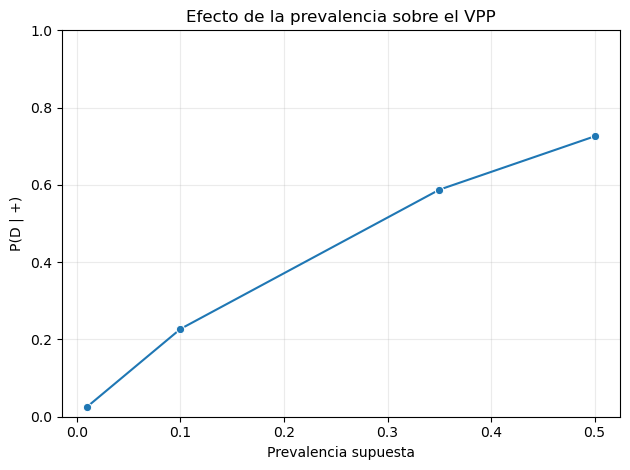

In [13]:
escenarios = []

for prevalencia in [0.50, 0.35, 0.10, 0.01]:
    vpp = (
        sensibilidad * prevalencia
        / (
            sensibilidad * prevalencia
            + (1 - especificidad) * (1 - prevalencia)
        )
    )
    escenarios.append({
        "prevalencia": prevalencia,
        "VPP_estimado": vpp
    })

tabla_prevalencia = pd.DataFrame(escenarios)
print(tabla_prevalencia.round(4))

sns.lineplot(
    data=tabla_prevalencia,
    x="prevalencia", y="VPP_estimado", marker="o"
)
plt.ylim(0, 1)
plt.title("Efecto de la prevalencia sobre el VPP")
plt.xlabel("Prevalencia supuesta")
plt.ylabel("P(D | +)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [14]:
persona = pd.DataFrame({
    "Pregnancies": [2],
    "Glucose": [155],
    "BloodPressure": [78],
    "SkinThickness": [30],
    "Insulin": [160],
    "BMI": [34.0],
    "DiabetesPedigreeFunction": [0.55],
    "Age": [45]
})

p_persona = modelo.predict_proba(persona)[0, 1]
clase_05 = int(p_persona >= 0.50)

print(f"Probabilidad estimada: {p_persona:.3f}")
print(f"Clase con umbral 0.50: {clase_05}")


Probabilidad estimada: 0.612
Clase con umbral 0.50: 1
